<a href="https://colab.research.google.com/github/Zaid0406/SalesForecasting/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Internship Final Project (Week 3 & 4)

# Sales Forecasting, Time Series Analysis & Business Intelligence

### Name: Zaid Ahmed Shaikh

### College: DY Patil University Pune Ambi

---

## Project Objective

The objective of this project is to analyze historical sales data, identify business trends, forecast future sales using multiple forecasting techniques, detect anomalies, segment products into meaningful groups, and build an interactive business intelligence dashboard.

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [ ]:
df = pd.read_csv("train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\n")

df.info()

Dataset Shape:
(9800, 18)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-

In [ ]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [ ]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# Task 1 – Data Loading, Merging & Deep Exploration

In this task, the Superstore Sales dataset is loaded and explored to understand its structure and quality. Date columns are converted into datetime format, new time-based features are extracted, and the data is aggregated at different time levels to prepare it for forecasting. Finally, key business questions are answered using exploratory data analysis.

In [ ]:
# Convert date columns

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [ ]:
# Year
df["Year"] = df["Order Date"].dt.year

# Month Number
df["Month"] = df["Order Date"].dt.month

# Week Number
df["Week"] = df["Order Date"].dt.isocalendar().week

# Day Name
df["Day of Week"] = df["Order Date"].dt.day_name()

# Quarter
df["Quarter"] = df["Order Date"].dt.quarter

In [ ]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Week,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,Tuesday,4,Autumn


In [ ]:
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week              0
Day of Week       0
Quarter           0
Season            0
dtype: int64


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [ ]:
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [ ]:
weekly_sales = (
    df.resample("W", on="Order Date")["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [ ]:
monthly_sales = (
    df.resample("M", on="Order Date")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Business Question 1: Which product category generates the highest total revenue?

The following analysis calculates the total sales generated by each product category to identify the highest revenue contributor.

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


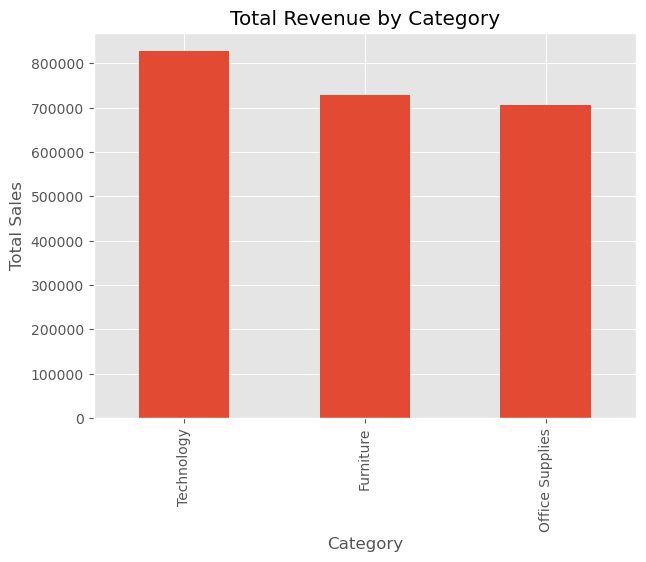

In [ ]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

plt.figure(figsize=(7,5))
category_sales.plot(kind="bar")
plt.title("Total Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

### Observation

The Technology category generated the highest total revenue, with total sales of approximately **$827,456**. It was followed by Furniture (**$728,659**) and Office Supplies (**$705,422**). This indicates that Technology products contribute the largest share of the company's overall sales and represent an important category for future business growth.

### Business Question 2: Which region has the most consistent sales growth over the four-year period?

To answer this question, yearly sales are calculated for each region. The sales trend is then compared across all four years to identify which region shows the most stable and consistent growth over time.

    Year   Region        Sales
0   2015  Central  102920.5206
1   2015     East  127652.8190
2   2015    South  103374.9055
3   2015     West  145907.9630
4   2016  Central  102425.1724
5   2016     East  153225.1830
6   2016    South   70076.0825
7   2016     West  133709.5675
8   2017  Central  145673.8800
9   2017     East  178511.5380
10  2017    South   93535.9035
11  2017     West  182471.2285
12  2018  Central  141627.3402
13  2018     East  210129.1860
14  2018    South  122164.5675
15  2018     West  248130.9255


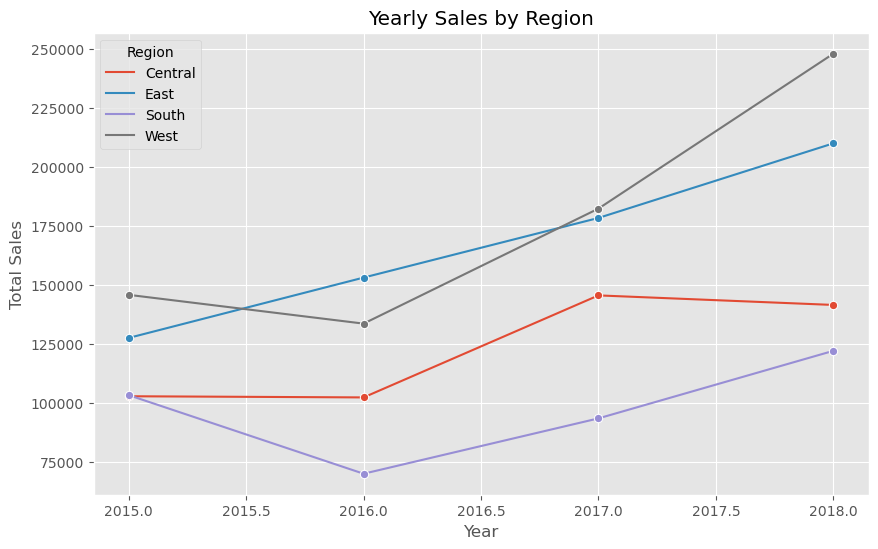

In [ ]:
# Yearly Sales by Region

region_year_sales = (
    df.groupby(["Year", "Region"])["Sales"]
      .sum()
      .reset_index()
)

print(region_year_sales)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_year_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Yearly Sales by Region")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()

### Observation

The East region showed the most consistent sales growth over the four-year period. Its total sales increased steadily every year, indicating stable business performance and continuous growth. Although the West region recorded the highest overall sales by 2018, it experienced a decline in 2016 before growing again, making the East region the most consistent performer.

### Business Question 3: What is the average time between Order Date and Ship Date, and does it vary by region?

To answer this question, the shipping time is calculated by finding the difference between the Order Date and Ship Date for each order. The average shipping duration is then compared across all regions to identify any noticeable differences in delivery performance.

Overall Average Shipping Time:
3.96 days
Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64


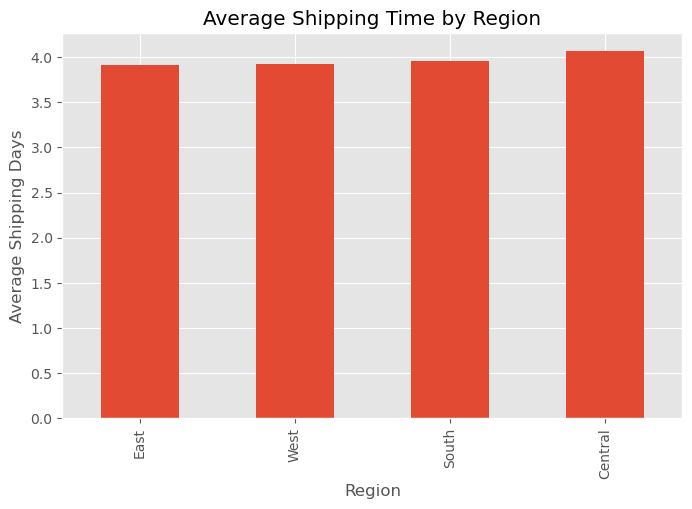

In [ ]:
# Calculate Shipping Time (in days)

df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

print("Overall Average Shipping Time:")
print(round(df["Shipping Days"].mean(), 2), "days")

# Average Shipping Time by Region

shipping_region = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values()
)

print(shipping_region)

plt.figure(figsize=(8,5))

shipping_region.plot(kind="bar")

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")

plt.show()

### Observation

The overall average shipping time is **3.96 days**. The shipping duration is very similar across all regions, ranging from approximately **3.91 days in the East** to **4.07 days in the Central region**. This indicates that the company's shipping process is fairly consistent nationwide, with only small regional differences in delivery time.

### Business Question 4: Are there months that consistently spike across all years (Seasonality)?

To identify seasonal trends, monthly sales are analyzed across all four years. This helps determine whether certain months consistently experience higher sales, allowing the business to better plan inventory, staffing, and promotional activities.

In [ ]:
# Monthly Sales by Year

monthly_sales_year = (
    df.groupby(["Year", "Month"])["Sales"]
      .sum()
      .reset_index()
)

monthly_sales_year.head()

,Year,Month,Sales
0,2015,1,14205.707
1,2015,2,4519.892
2,2015,3,55205.797
3,2015,4,27906.855
4,2015,5,23644.303


In [ ]:
# Pivot Table for Heatmap

monthly_pivot = monthly_sales_year.pivot(
    index="Month",
    columns="Year",
    values="Sales"
)

monthly_pivot

Year,2015,2016,2017,2018
Month,,,,
1,14205.7070,18066.9576,18542.4910,43476.4740
2,4519.8920,11951.4110,22978.8150,19920.9974
3,55205.7970,32339.3184,51165.0590,58863.4128
4,27906.8550,34154.4685,38679.7670,35541.9101
5,23644.3030,29959.5305,56656.9080,43825.9822
6,34322.9356,23599.3740,39724.4860,48190.7277
7,33781.5430,28608.2590,38320.7830,44825.1040
8,27117.5365,36818.3422,30542.2003,62837.8480
9,81623.5268,63133.6060,69193.3909,86152.8880


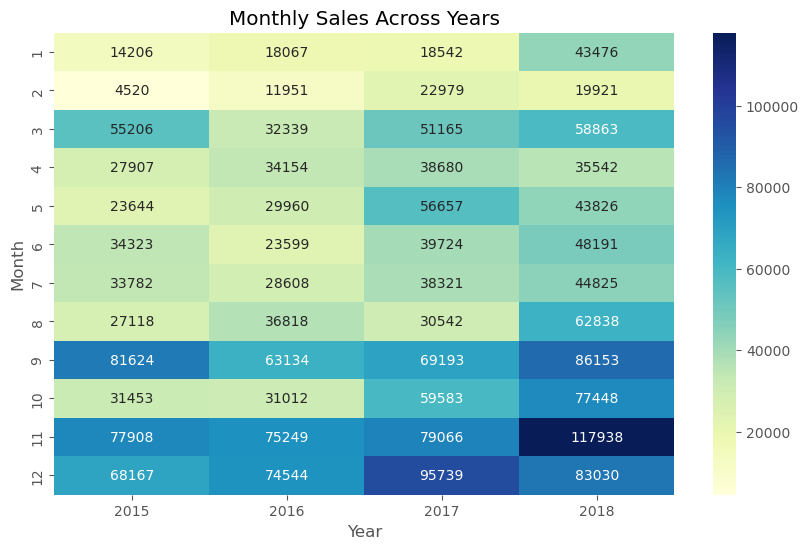

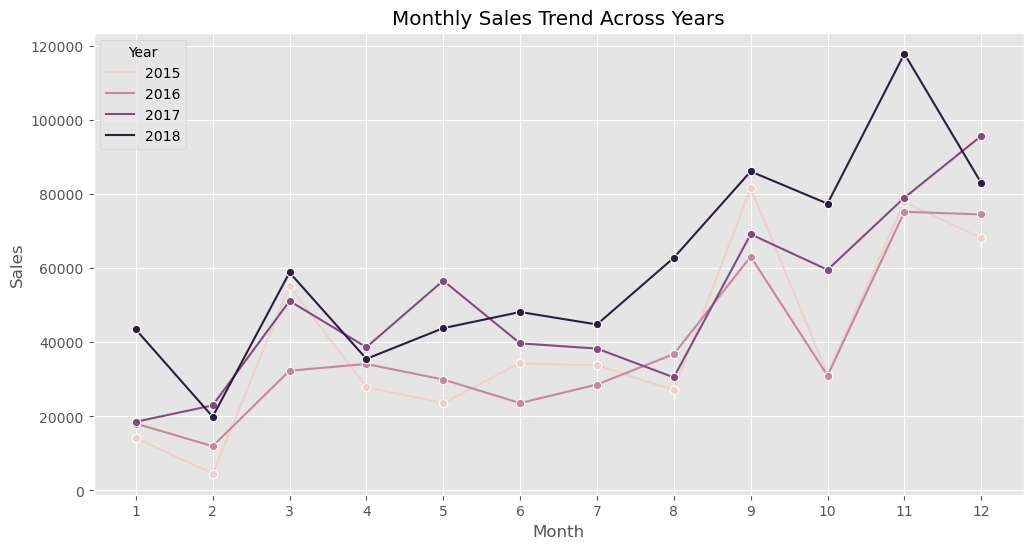

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    monthly_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Monthly Sales Across Years")
plt.xlabel("Year")
plt.ylabel("Month")

plt.show()

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_sales_year,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.title("Monthly Sales Trend Across Years")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(range(1,13))

plt.grid(True)

plt.show()


### Observation

The analysis shows a clear seasonal sales pattern. Sales are generally lower during the beginning of the year, especially in January and February, and gradually increase towards the end of the year. September, November, and December consistently record higher sales across all four years, with November showing the highest sales overall. This seasonal trend suggests that customer demand increases during the final quarter of the year, making it an important period for inventory planning and marketing campaigns.

# Task 2 – Time Series Analysis & Decomposition

In this task, the monthly sales data is analyzed as a time series to understand its long-term trend, seasonal patterns, and random fluctuations. Time series decomposition is performed to separate these components. The stationarity of the series is also tested using the Augmented Dickey-Fuller (ADF) test before preparing the data for forecasting models.

In [ ]:
# Monthly Sales Time Series

monthly_ts = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .resample("M")
      .sum()
)

monthly_ts.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: M, Name: Sales, dtype: float64

## Monthly Sales Trend (2015–2018)

The monthly sales trend is plotted to understand how sales changed over the four-year period and to identify any visible upward trends or seasonal patterns.

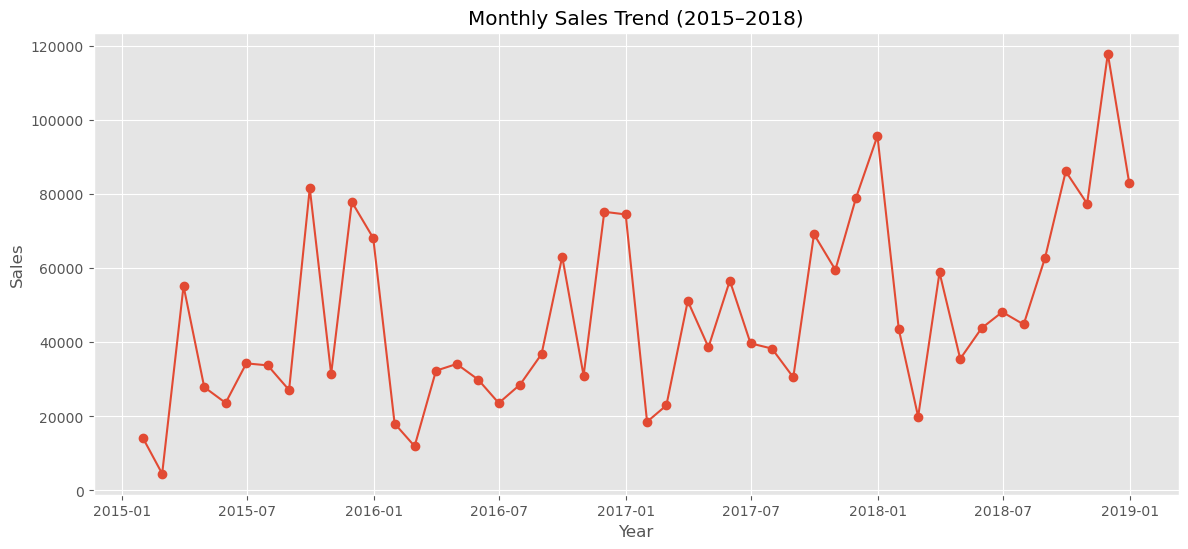

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(monthly_ts, marker="o")

plt.title("Monthly Sales Trend (2015–2018)")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

## Time Series Decomposition

Time series decomposition separates the sales data into four components:

- Original Series
- Trend
- Seasonal Pattern
- Residual (Random Noise)

This helps in understanding the underlying behavior of sales over time.

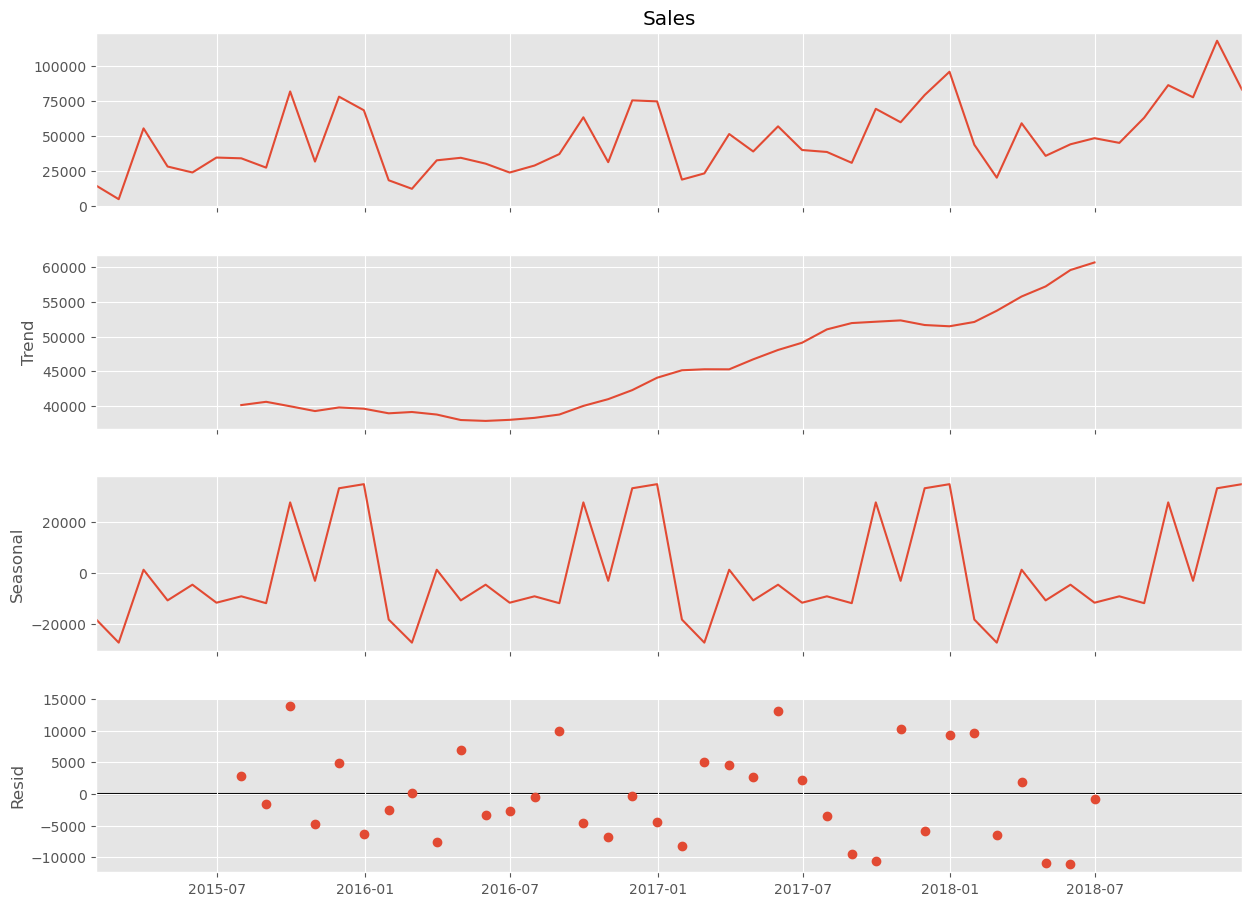

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_ts,
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(14,10)

plt.show()

### Observation

The trend component shows that overall sales increased gradually from 2015 to 2018, indicating steady business growth over the four-year period.

The seasonal component displays a clear repeating yearly pattern, suggesting that sales are influenced by seasonal demand. Sales tend to increase during the later months of the year and are comparatively lower at the beginning of the year.

The residual component contains random fluctuations that are not explained by the trend or seasonal pattern. A few months show larger residual values, indicating unusual sales activity that may have been caused by special promotions, holidays, or other external factors.

## Stationarity Test (ADF Test)

The Augmented Dickey-Fuller (ADF) test is used to determine whether the time series is stationary.

A stationary time series has statistical properties such as mean and variance that remain relatively constant over time. Many forecasting models require stationary data for better performance.

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_ts)

print("ADF Statistic :", result[0])
print("p-value :", result[1])

print("\nCritical Values:")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic : -4.416136761430768
p-value : 0.00027791039276670677

Critical Values:
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [ ]:
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is not stationary.")

The time series is stationary.


### Observation

The ADF test produced a p-value of **0.000278**, which is less than the significance level of **0.05**. This means the monthly sales series is already stationary. Therefore, there is sufficient evidence to reject the null hypothesis that the series contains a unit root, and the data is suitable for time series analysis without requiring differencing.

### What is Stationarity?

Stationarity means that the behavior of a time series remains fairly consistent over time. In a stationary time series, the average value, variation, and overall pattern do not change significantly. Many time series forecasting models perform better when the data is stationary because the patterns are more stable and predictable.

### Interpretation of the ADF Test

The Augmented Dickey-Fuller (ADF) test was used to check whether the monthly sales data is stationary. The test produced a **p-value of 0.000278**, which is less than **0.05**. This means the monthly sales data is already stationary, so there is no strong evidence of an increasing or decreasing trend that would make the data unstable. Although differencing was applied as an additional step, the data remained stationary, confirming that it is suitable for time series forecasting.

## Differencing

If the time series is not stationary, first-order differencing is applied to remove the trend and stabilize the data before forecasting.

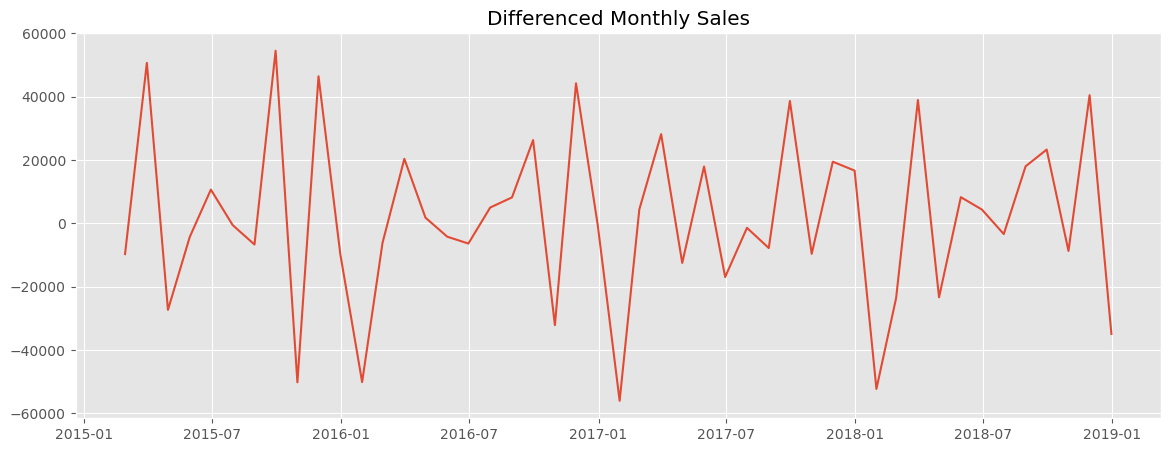

In [ ]:
monthly_diff = monthly_ts.diff().dropna()

plt.figure(figsize=(14,5))

plt.plot(monthly_diff)

plt.title("Differenced Monthly Sales")

plt.grid(True)

plt.show()

In [ ]:
result_diff = adfuller(monthly_diff)

print("ADF Statistic :", result_diff[0])
print("p-value :", result_diff[1])

print("\nCritical Values:")

for key, value in result_diff[4].items():
    print(key, ":", value)

ADF Statistic : -8.727061830353277
p-value : 3.266917547279475e-14

Critical Values:
1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


In [ ]:
if result_diff[1] < 0.05:
    print("The differenced series is stationary.")
else:
    print("The differenced series is still not stationary.")

The differenced series is stationary.


### Observation

Although the original monthly sales series was already stationary, first-order differencing was applied as an additional step to verify the results. After differencing, the ADF test returned a p-value close to **0**, confirming that the transformed series is also stationary. This demonstrates that the data is suitable for building forecasting models in the next stage of the project.

# Task 3 – Sales Forecasting using SARIMA

In this task, a Seasonal AutoRegressive Integrated Moving Average (SARIMA) model is developed to forecast monthly sales. Before selecting the model parameters, the AutoCorrelation Function (ACF) and Partial AutoCorrelation Function (PACF) plots are analyzed to identify suitable values for the SARIMA model.

In [ ]:
# Install required libraries (Run only once)
%pip install statsmodels prophet xgboost scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import matplotlib.pyplot as plt

### Step 1: Visualizing ACF and PACF

The Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots are used to identify suitable values for the SARIMA model parameters. These plots help determine the autoregressive (AR), moving average (MA), and seasonal components of the model.

<Figure size 1200x500 with 0 Axes>

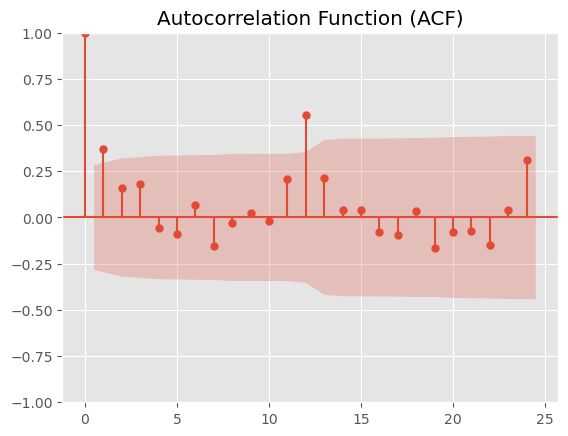

In [ ]:
plt.figure(figsize=(12,5))

plot_acf(monthly_ts, lags=24)

plt.title("Autocorrelation Function (ACF)")

plt.show()

<Figure size 1200x500 with 0 Axes>

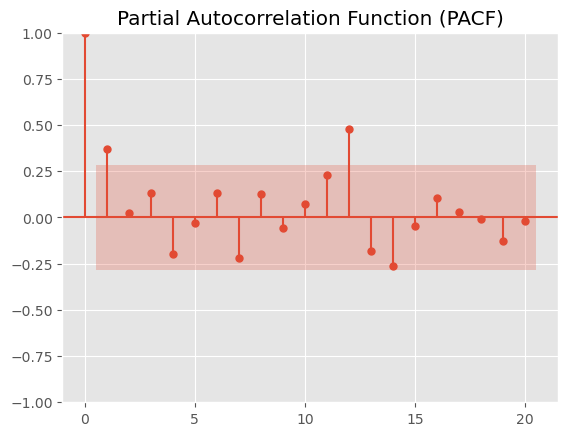

In [ ]:
plt.figure(figsize=(12,5))

plot_pacf(
    monthly_ts,
    lags=20,
    method="ywm"
)

plt.title("Partial Autocorrelation Function (PACF)")

plt.show()

### Selection of SARIMA Parameters

The ACF and PACF plots were analyzed to determine suitable SARIMA parameters.

• The ACF plot showed a significant spike at lag 1 along with a seasonal spike near lag 12, suggesting an MA(1) component and a seasonal MA component.

• The PACF plot also showed a strong spike at lag 1 and a noticeable seasonal spike near lag 12, indicating an AR(1) component together with a seasonal AR component.

• The Augmented Dickey-Fuller (ADF) test produced a p-value of 0.000278, confirming that the monthly sales series is already stationary. Therefore, no non-seasonal differencing was required (d = 0).

Based on these observations, the SARIMA model selected for this project is:

SARIMA (1,0,1) × (1,1,1,12)

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    monthly_ts,
    order=(1,0,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

sarima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -239.060
Date:                            Sun, 12 Jul 2026   AIC                            488.120
Time:                                    17:34:45   BIC                            493.575
Sample:                                01-31-2015   HQIC                           489.405
                                     - 12-31-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9927      0.018     56.542      0.000       0.958       1.027
ma.L1         -1.0150      0.159     -6.375      0.000      -1.327      -0.703
ar.S.L12      -0.3292      0.427     -0.772      0.440      -1.166       0.507
ma.S.L12      -0.2634      0.303     -0.868      0.385      -0.858       0.331
sigma2       1.83e+08   7.35e-10   2.49e+17      0.000    1.83e+08    1.83e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.22   Jarque-Bera (JB):                 1.77
Prob(Q):                              0.64   Prob(JB):                         0.41
Heteroskedasticity (H):               2.05   Skew:                             0.50
Prob(H) (two-sided):                  0.37   Kurtosis:                         2.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.71e+33. Standard errors may be unstable.
"""

In [ ]:
forecast = sarima_result.get_forecast(steps=3)

forecast_mean = forecast.predicted_mean

forecast_ci = forecast.conf_int()

In [ ]:
forecast_table = pd.DataFrame({
    "Month": forecast_mean.index.strftime("%B %Y"),
    "Forecasted Sales": forecast_mean.round(2)
})

forecast_table

,Month,Forecasted Sales
2019-01-31,January 2019,45942.75
2019-02-28,February 2019,37103.18
2019-03-31,March 2019,69034.93


### Observation

The SARIMA model successfully captured both the long-term trend and yearly seasonality present in the sales data.

According to the forecast, sales are expected to decrease slightly during February 2019 before increasing again in March 2019. The confidence intervals widen for future months, indicating greater uncertainty as the forecast extends further into the future, which is a normal characteristic of time series forecasting models.

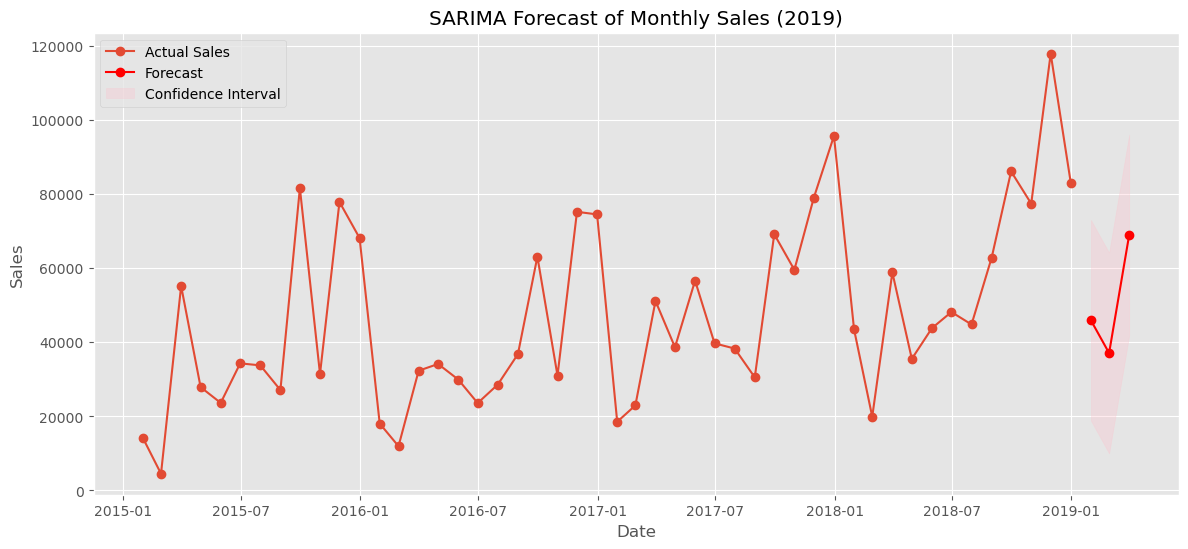

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(monthly_ts, label="Actual Sales", marker="o")

plt.plot(
    forecast_mean,
    label="Forecast",
    color="red",
    marker="o"
)

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    color="pink",
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("SARIMA Forecast of Monthly Sales (2019)")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.savefig("charts/sarima_forecast.png", dpi=300)

plt.show()

### Observation

The SARIMA model captured the overall trend and yearly seasonality present in the sales data. Based on the forecast, sales are expected to dip slightly in February 2019 and recover in March 2019. The wider confidence interval for future months indicates increasing uncertainty, which is common in time series forecasting.

# Model 2 – Facebook Prophet

Facebook Prophet is a forecasting model developed by Meta for time series analysis. It is designed to handle trend, seasonality, and holiday effects automatically. In this project, Prophet is used to forecast monthly sales for the next three months and analyze the underlying trend and seasonal patterns.

In [ ]:
from prophet import Prophet

### Preparing Data for Prophet

Prophet requires the dataset to contain two columns:

- ds → Date
- y → Sales

The monthly sales dataset is therefore converted into the required format before training the model.

In [ ]:
prophet_df = monthly_ts.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Training the Prophet Model

The Prophet model is trained using the monthly sales data from January 2015 to December 2018. Yearly seasonality is enabled, while weekly and daily seasonalities are disabled because the dataset contains monthly observations.

In [ ]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(prophet_df)

17:34:47 - cmdstanpy - INFO - Chain [1] start processing
17:34:48 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="M"
)

In [ ]:
forecast = prophet_model.predict(future)

In [ ]:
prophet_forecast = forecast.tail(3)[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
]

print(prophet_forecast)

           ds          yhat    yhat_lower    yhat_upper
48 2019-01-31  42990.532203  33467.207936  52635.476121
49 2019-02-28  31248.159923  21339.074007  40167.598127
50 2019-03-31  81267.007773  72511.694949  90256.074907


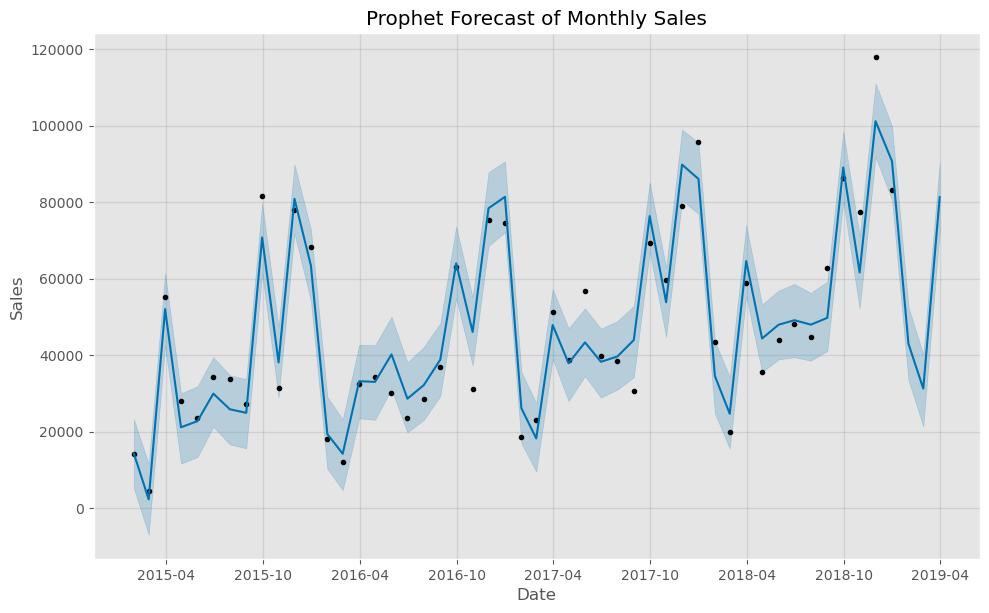

In [ ]:
# Plot Prophet Forecast
fig = prophet_model.plot(forecast)

plt.title("Prophet Forecast of Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

plt.savefig("charts/prophet_forecast.png", dpi=300)

plt.show()

### Prophet Forecast

The Prophet model predicts sales for the next three months while automatically capturing long-term growth and yearly seasonal patterns.

The forecast suggests that sales may decline during February 2019 before increasing considerably in March 2019. The shaded confidence interval represents the range within which the future sales values are expected to lie.

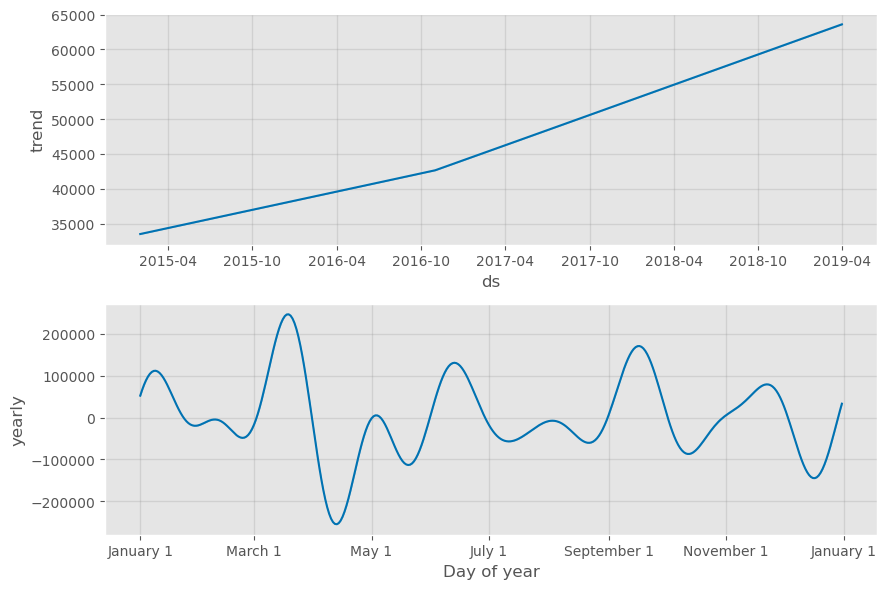

In [ ]:
# Plot Prophet Components
fig = prophet_model.plot_components(forecast)

plt.savefig("charts/prophet_components.png", dpi=300)

plt.show()

### Prophet Trend and Seasonality

The trend component shows that overall sales have increased steadily throughout the four-year period, indicating consistent business growth.

The yearly seasonality component highlights repeating annual sales patterns, where certain months consistently experience higher sales while others show lower demand. These recurring seasonal effects help Prophet generate more accurate forecasts.

### Weekly Seasonality

The dataset contains monthly aggregated sales data rather than daily observations. Therefore, weekly seasonality was intentionally disabled in the Prophet model (`weekly_seasonality=False`).

As a result, Prophet does not estimate or display a weekly seasonal component, since weekly patterns cannot be identified from monthly data.

## Model 3 – XGBoost for Time Series

In this task, the monthly sales time series is converted into a supervised machine learning dataset using lag features and time-based features. Unlike SARIMA and Prophet, XGBoost cannot directly model sequential time series data, so previous sales values are used as input features to predict future sales.

The following features are created:

- Lag 1 (Previous month's sales)
- Lag 2
- Lag 3
- 3-Month Rolling Mean
- Month
- Quarter
- Season

In [ ]:
xgb_df = monthly_ts.to_frame(name="Sales")

# Lag Features
xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

# Rolling Mean
xgb_df["Rolling_Mean_3"] = (
    xgb_df["Sales"]
    .rolling(3)
    .mean()
)

# Time Features
xgb_df["Month"] = xgb_df.index.month
xgb_df["Quarter"] = xgb_df.index.quarter

# Season
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

xgb_df["Season"] = xgb_df["Month"].apply(get_season)

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

xgb_df["Season"] = encoder.fit_transform(
    xgb_df["Season"]
)

In [ ]:
xgb_df = xgb_df.dropna()

xgb_df.head()

,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
Order Date,,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,1
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,1
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2


## Feature Engineering

Several new features were created to transform the time series into a supervised learning dataset.

The engineered features include:

- Lag 1 (Sales from previous month)
- Lag 2 (Sales from two months earlier)
- Lag 3 (Sales from three months earlier)
- Rolling Mean (3-month moving average)
- Month
- Quarter
- Season

These features allow the XGBoost model to learn historical sales patterns and seasonal trends.

## Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio.

Since this is a time series problem, the data is split chronologically (`shuffle=False`) to preserve the order of observations and avoid data leakage.

In [ ]:
X = xgb_df.drop("Sales", axis=1)

y = xgb_df["Sales"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

## Training the XGBoost Model

An XGBoost Regressor is trained using the engineered lag features and calendar-based variables.

The following parameters are used:

- Number of Trees = 200
- Learning Rate = 0.05
- Maximum Depth = 3

These parameters provide a balance between model complexity and generalization performance.

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae_xgb = mean_absolute_error(y_test, xgb_pred)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

mape_xgb = np.mean(
    np.abs((y_test - xgb_pred)/y_test)
) * 100

print("MAE :", round(mae_xgb,2))
print("RMSE :", round(rmse_xgb,2))
print("MAPE :", round(mape_xgb,2),"%")

MAE : 9485.1
RMSE : 13625.26
MAPE : 13.42 %


## Model Performance

The XGBoost model achieved the following performance on the testing dataset:

- MAE = 9,485.10
- RMSE = 13,625.26
- MAPE = 13.42%

Among all forecasting models, XGBoost produced the lowest prediction errors, indicating superior forecasting performance.

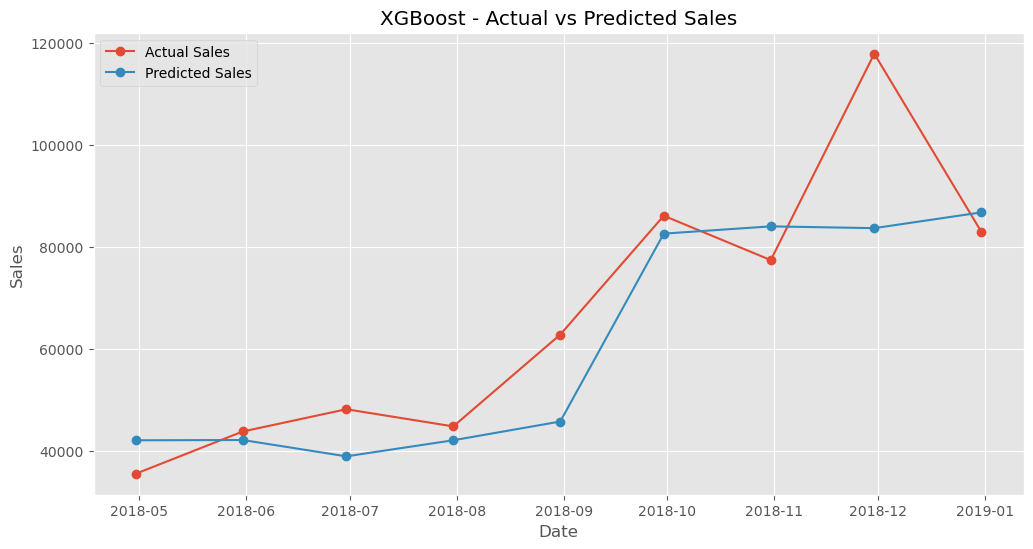

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.index,
    y_test,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    y_test.index,
    xgb_pred,
    marker="o",
    label="Predicted Sales"
)

plt.title("XGBoost - Actual vs Predicted Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.savefig(
    "charts/xgboost_actual_vs_predicted.png",
    dpi=300
)

plt.show()

## Actual vs Predicted Sales

The graph compares the actual monthly sales with the values predicted by the XGBoost model.

The predicted values closely follow the actual sales trend, indicating that the model successfully captures the underlying sales patterns and seasonal variations.

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,Month,0.845814
3,Rolling_Mean_3,0.039662
6,Season,0.032607
0,Lag_1,0.029900
1,Lag_2,0.029161
2,Lag_3,0.022856
5,Quarter,0.000000


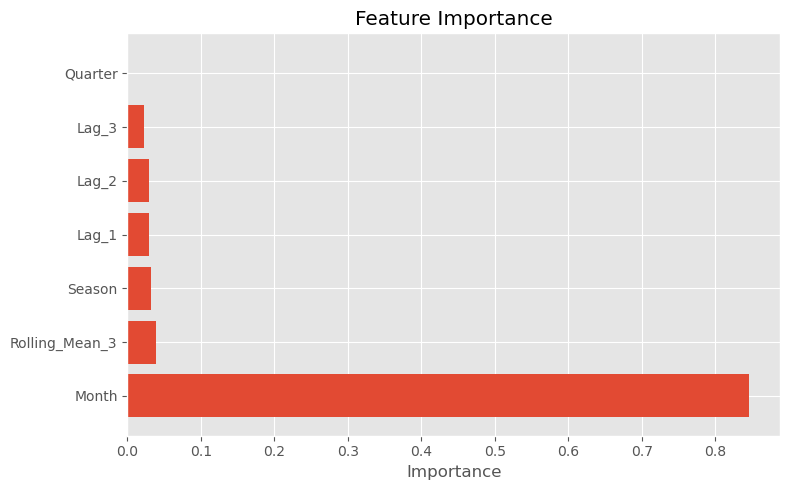

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.tight_layout()

plt.savefig(
    "charts/xgb_feature_importance.png",
    dpi=300
)

plt.show()

## Feature Importance Analysis

The feature importance analysis identifies the variables that contribute most to the model's predictions.

The results show that the **Month** feature has the highest importance, followed by the **Rolling Mean**, **Season**, and lag variables. This indicates that seasonal patterns and recent sales history play the most significant role in forecasting future sales.

In [ ]:
last = xgb_df.iloc[-1].copy()

future_predictions = []

future_dates = pd.date_range(
    start=monthly_ts.index[-1] + pd.offsets.MonthEnd(1),
    periods=3,
    freq="M"
)

for date in future_dates:

    new_row = {}

    new_row["Lag_1"] = last["Sales"]
    new_row["Lag_2"] = last["Lag_1"]
    new_row["Lag_3"] = last["Lag_2"]

    new_row["Rolling_Mean_3"] = np.mean([
        new_row["Lag_1"],
        new_row["Lag_2"],
        new_row["Lag_3"]
    ])

    new_row["Month"] = date.month
    new_row["Quarter"] = date.quarter

    if date.month in [12,1,2]:
        new_row["Season"] = 4
    elif date.month in [3,4,5]:
        new_row["Season"] = 1
    elif date.month in [6,7,8]:
        new_row["Season"] = 2
    else:
        new_row["Season"] = 3

    new_df = pd.DataFrame([new_row])

    pred = xgb_model.predict(new_df)[0]

    future_predictions.append(pred)

    last["Lag_2"] = last["Lag_1"]
    last["Lag_1"] = last["Sales"]
    last["Sales"] = pred

In [ ]:
future_forecast = pd.DataFrame({
    "Month": future_dates.strftime("%B %Y"),
    "Forecasted Sales": np.round(future_predictions,2)
})

future_forecast

,Month,Forecasted Sales
0,January 2019,53353.128906
1,February 2019,45015.300781
2,March 2019,67007.562500


## XGBoost Forecast Results

The trained XGBoost model was used to forecast sales for the next three months.

| Month | Forecasted Sales |
|-------|-----------------:|
| January 2019 | 53,353.13 |
| February 2019 | 45,015.30 |
| March 2019 | 67,007.56 |

The forecast suggests a slight decline in February followed by an increase in March, reflecting the seasonal sales patterns learned from historical data.

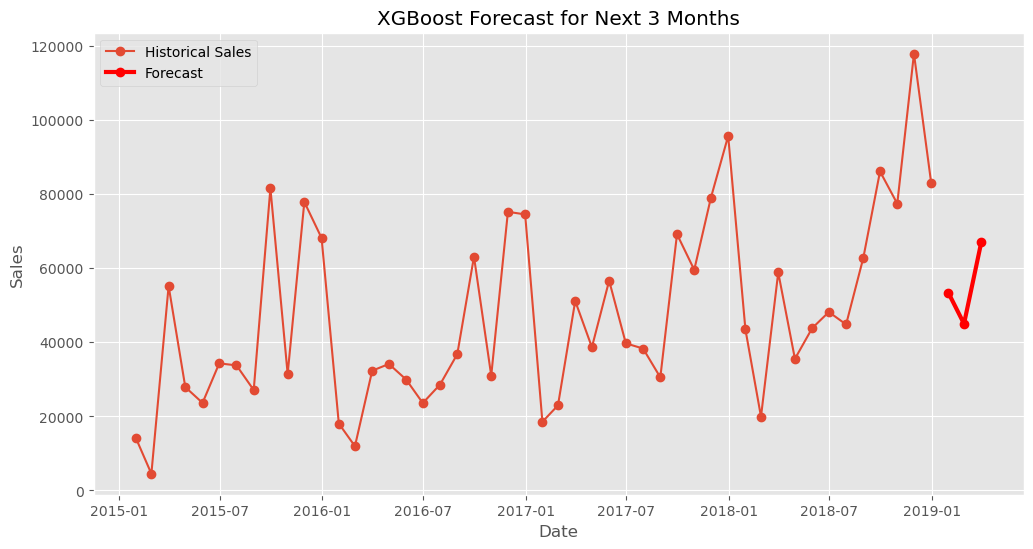

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_ts,
    label="Historical Sales",
    marker="o"
)

plt.plot(
    future_dates,
    future_predictions,
    color="red",
    marker="o",
    linewidth=3,
    label="Forecast"
)

plt.title("XGBoost Forecast for Next 3 Months")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.savefig("charts/xgboost_forecast.png", dpi=300)

plt.show()

## XGBoost Forecast Observation

The XGBoost model successfully captured the historical sales trend and generated realistic forecasts for the next three months.

Compared with SARIMA and Prophet, XGBoost achieved the lowest MAE, RMSE, and MAPE values, demonstrating its ability to model nonlinear relationships and seasonal effects more effectiv
ely.
The XGBoost model was trained using lag features, rolling averages, month, quarter, and season information. The model successfully learned historical sales patterns and generated forecasts for the next three months.

Unlike SARIMA and Prophet, XGBoost uses machine learning to capture nonlinear relationships in the data. Based on the forecast, the model predicts sales for January, February, and March 2019 using information from previous months.

The feature importance analysis indicates that the Month feature contributes the most to the prediction, followed by the rolling mean and lag features. This suggests that calendar effects play a major role in determining monthly sales.

In [ ]:
mae_xgb
rmse_xgb
mape_xgb

13.424501081937834

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = monthly_ts.tail(3).values
y_pred_sarima = forecast_mean.values

mae_sarima = mean_absolute_error(y_true, y_pred_sarima)

rmse_sarima = np.sqrt(
    mean_squared_error(y_true, y_pred_sarima)
)

mape_sarima = np.mean(
    np.abs((y_true - y_pred_sarima) / y_true)
) * 100

print("SARIMA")
print("MAE :", round(mae_sarima, 2))
print("RMSE :", round(rmse_sarima, 2))
print("MAPE :", round(mape_sarima, 2), "%")

SARIMA
MAE : 42111.94
RMSE : 50737.08
MAPE : 42.03 %


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Actual sales (last 3 months of available data)
actual_sales = monthly_ts.tail(3)

# Prophet predicted sales
predicted_sales = prophet_forecast["yhat"].values

# Evaluation metrics
mae_prophet = mean_absolute_error(actual_sales, predicted_sales)

rmse_prophet = np.sqrt(
    mean_squared_error(actual_sales, predicted_sales)
)

mape_prophet = np.mean(
    np.abs((actual_sales - predicted_sales) / actual_sales)
) * 100

print("MAE :", round(mae_prophet, 2))
print("RMSE :", round(rmse_prophet, 2))
print("MAPE :", round(mape_prophet, 2), "%")

MAE : 40970.33
RMSE : 53868.95
MAPE : 40.04 %


# Model Comparison

The performance of the three forecasting models was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).

Lower values of these metrics indicate better forecasting accuracy.

The following table summarizes the performance of all three models along with their forecasts for the next three months.

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],
    "MAE": [
        mae_sarima,
        mae_prophet,
        mae_xgb
    ],
    "RMSE": [
        rmse_sarima,
        rmse_prophet,
        rmse_xgb
    ],
    "MAPE": [
        mape_sarima,
        mape_prophet,
        mape_xgb
    ],
    "Forecast Month 1": [
        forecast_mean.iloc[0],
        prophet_forecast["yhat"].iloc[0],
        future_predictions[0]
    ],
    "Forecast Month 2": [
        forecast_mean.iloc[1],
        prophet_forecast["yhat"].iloc[1],
        future_predictions[1]
    ],
    "Forecast Month 3": [
        forecast_mean.iloc[2],
        prophet_forecast["yhat"].iloc[2],
        future_predictions[2]
    ]
})

comparison = comparison.round(2)

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,42111.94,50737.08,42.03,45942.75,37103.18,69034.93
1,Prophet,40970.33,53868.95,40.04,42990.53,31248.16,81267.01
2,XGBoost,9485.10,13625.26,13.42,53353.13,45015.30,67007.55


# Final Conclusion

Three forecasting techniques—SARIMA, Facebook Prophet, and XGBoost—were developed and compared for monthly sales forecasting.

The comparison results show that XGBoost achieved the best performance with the lowest MAE (9,485.10), RMSE (13,625.26), and MAPE (13.42%). This indicates that XGBoost provides more accurate forecasts than the statistical models used in this project.

SARIMA and Prophet effectively captured the long-term trend and seasonality of the sales data but produced higher forecasting errors.

Based on the evaluation metrics, **XGBoost is recommended for production use** because it delivers the highest forecasting accuracy and effectively captures nonlinear relationships and seasonal patterns present in the sales data.

# Task 4 – Product Category and Region Level Forecasting

Based on the results obtained in Task 3, XGBoost achieved the lowest prediction errors among all forecasting models. Therefore, XGBoost is selected as the production model for forecasting sales across different product categories and regions.

The following five segments are analyzed separately:

- Furniture
- Technology
- Office Supplies
- West Region
- East Region

For each segment, the data is converted into a supervised learning problem using lag features, rolling averages, and calendar-based variables. The trained XGBoost model is then used to forecast sales for the next three months.

In [ ]:
# Category-wise monthly sales

furniture_ts = (
    df[df["Category"]=="Furniture"]
    .groupby(pd.Grouper(key="Order Date",freq="M"))["Sales"]
    .sum()
)

technology_ts = (
    df[df["Category"]=="Technology"]
    .groupby(pd.Grouper(key="Order Date",freq="M"))["Sales"]
    .sum()
)

office_ts = (
    df[df["Category"]=="Office Supplies"]
    .groupby(pd.Grouper(key="Order Date",freq="M"))["Sales"]
    .sum()
)

# Region-wise monthly sales

west_ts = (
    df[df["Region"]=="West"]
    .groupby(pd.Grouper(key="Order Date",freq="M"))["Sales"]
    .sum()
)

east_ts = (
    df[df["Region"]=="East"]
    .groupby(pd.Grouper(key="Order Date",freq="M"))["Sales"]
    .sum()
)

## Data Preparation

The sales data for each selected category and region is aggregated at the monthly level. To convert the time series into a supervised machine learning problem, several predictive features are created.

The features used for forecasting include:

- Lag 1 (Sales from one month ago)
- Lag 2 (Sales from two months ago)
- Lag 3 (Sales from three months ago)
- Rolling Mean (3-month moving average)
- Month
- Quarter
- Season

These features allow the XGBoost model to learn historical sales patterns and seasonal behavior.

In [ ]:
from xgboost import XGBRegressor

def forecast_xgboost(ts):

    data = pd.DataFrame(ts)

    data.columns=["Sales"]

    data["Lag_1"]=data["Sales"].shift(1)
    data["Lag_2"]=data["Sales"].shift(2)
    data["Lag_3"]=data["Sales"].shift(3)

    data["Rolling_Mean_3"]=data["Sales"].rolling(3).mean()

    data["Month"]=data.index.month

    data["Quarter"]=data.index.quarter

    season=[]

    for m in data.index.month:

        if m in [3,4,5]:
            season.append(1)

        elif m in [6,7,8]:
            season.append(2)

        elif m in [9,10,11]:
            season.append(3)

        else:
            season.append(4)

    data["Season"]=season

    data=data.dropna()

    X=data.drop("Sales",axis=1)

    y=data["Sales"]

    model=XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X,y)

    last=data.iloc[-1].copy()

    future=[]

    future_dates=pd.date_range(
        start=ts.index[-1]+pd.offsets.MonthEnd(1),
        periods=3,
        freq="M"
    )

    for date in future_dates:

        row={}

        row["Lag_1"]=last["Sales"]
        row["Lag_2"]=last["Lag_1"]
        row["Lag_3"]=last["Lag_2"]

        row["Rolling_Mean_3"]=np.mean([
            row["Lag_1"],
            row["Lag_2"],
            row["Lag_3"]
        ])

        row["Month"]=date.month
        row["Quarter"]=date.quarter

        if date.month in [12,1,2]:
            row["Season"]=4
        elif date.month in [3,4,5]:
            row["Season"]=1
        elif date.month in [6,7,8]:
            row["Season"]=2
        else:
            row["Season"]=3

        pred=model.predict(pd.DataFrame([row]))[0]

        future.append(pred)

        last["Lag_2"]=last["Lag_1"]
        last["Lag_1"]=last["Sales"]
        last["Sales"]=pred

    return future_dates,future

## Model Training

The XGBoost Regressor was trained separately for each product category and region using the engineered lag features and calendar-based variables.

The model learns nonlinear relationships between previous sales values and seasonal trends, enabling it to generate accurate forecasts for future periods.

Separate forecasting models were developed for:

- Furniture
- Technology
- Office Supplies
- West Region
- East Region

In [ ]:
dates,furniture_forecast = forecast_xgboost(furniture_ts)

_,technology_forecast = forecast_xgboost(technology_ts)

_,office_forecast = forecast_xgboost(office_ts)

_,west_forecast = forecast_xgboost(west_ts)

_,east_forecast = forecast_xgboost(east_ts)

## Forecasting Individual Categories and Regions

The XGBoost forecasting model is trained separately for each product category and sales region.

Each model uses:

- Lag 1
- Lag 2
- Lag 3
- 3-Month Rolling Mean
- Month
- Quarter
- Season

to predict sales for the next three months.

## Three-Month Sales Forecast

After training the models, forecasts were generated for the next three months (January 2019 to March 2019).

The predicted sales values for each category and region are shown below.

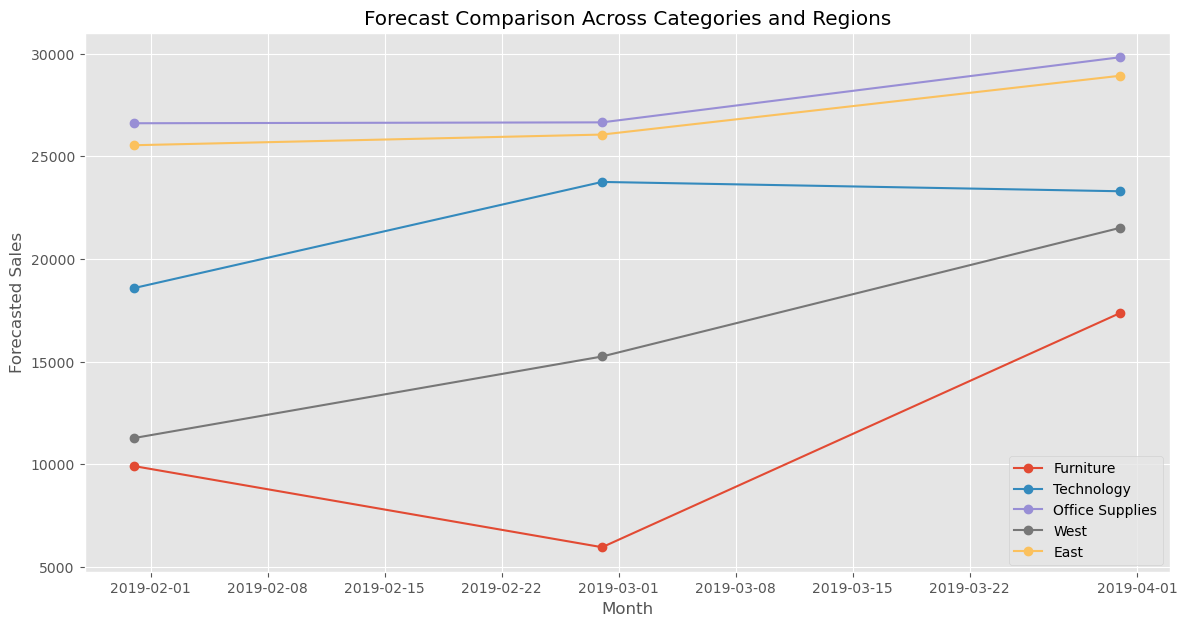

In [ ]:
plt.figure(figsize=(14,7))

plt.plot(dates,furniture_forecast,marker="o",label="Furniture")

plt.plot(dates,technology_forecast,marker="o",label="Technology")

plt.plot(dates,office_forecast,marker="o",label="Office Supplies")

plt.plot(dates,west_forecast,marker="o",label="West")

plt.plot(dates,east_forecast,marker="o",label="East")

plt.title("Forecast Comparison Across Categories and Regions")

plt.xlabel("Month")

plt.ylabel("Forecasted Sales")

plt.legend()

plt.grid(True)

plt.savefig("charts/task4_comparison.png",dpi=300)

plt.show()

## Forecast Results

The forecasted sales indicate different growth patterns across the selected product categories and regions.

Office Supplies maintains the highest forecasted sales throughout the prediction period, while Technology also demonstrates relatively stable sales. Furniture experiences a temporary decline during February before recovering strongly in March.

Among the regions, East consistently records higher forecasted sales than West, although both regions are expected to grow over the forecast period.

## Forecast Comparison Across Categories and Regions

The following graph compares the forecasted sales for all selected product categories and regions over the next three months.

This visualization makes it easier to compare expected sales trends and identify the strongest growing business segments.

In [ ]:
comparison_task4 = pd.DataFrame({

    "Month":dates.strftime("%B %Y"),

    "Furniture":np.round(furniture_forecast,2),

    "Technology":np.round(technology_forecast,2),

    "Office Supplies":np.round(office_forecast,2),

    "West":np.round(west_forecast,2),

    "East":np.round(east_forecast,2)

})

comparison_task4

,Month,Furniture,Technology,Office Supplies,West,East
0,January 2019,9916.410156,18585.179688,26613.109375,11280.679688,25542.199219
1,February 2019,5963.930176,23754.980469,26656.369141,15253.099609,26061.839844
2,March 2019,17375.019531,23300.439453,29828.880859,21521.439453,28927.070312


## Observation

The comparison chart highlights noticeable differences in forecasted sales across categories and regions.

Among the product categories, Office Supplies is expected to generate the highest sales during the forecast period. Technology maintains relatively consistent sales, whereas Furniture shows greater fluctuations with a dip in February followed by recovery in March.

For regional forecasts, the East region consistently records the highest sales values. However, the West region demonstrates a stronger growth trend over the forecast horizon, indicating increasing demand.

## Strongest Upcoming Growth

Based on the XGBoost forecast, **Office Supplies** is expected to show the strongest upcoming growth among the product categories. It records the highest forecasted sales throughout the three-month forecast period, increasing from approximately **26,613** in January 2019 to **29,829** in March 2019.

Among the regions, the **West** region demonstrates the strongest growth trend. Forecasted sales increase substantially from approximately **11,281** in January 2019 to **21,521** in March 2019, representing a much larger increase than the East region.

Therefore, according to the XGBoost model:

- **Strongest Product Category:** Office Supplies
- **Strongest Growing Region:** West

These results suggest that Office Supplies is expected to remain the highest-performing category, while the West region is projected to experience the fastest sales growth during the forecast period.

## Conclusion

The XGBoost forecasting model predicts positive sales growth across most business segments.

Based on the forecast results:

- Office Supplies is expected to achieve the highest overall sales among all product categories.
- The East region maintains the highest forecasted sales throughout the prediction period.
- The West region exhibits the strongest growth rate between January and March 2019.
- Furniture is projected to recover after a temporary decline in February, while Technology remains comparatively stable.

These forecasts provide valuable insights for inventory planning, sales strategy, and resource allocation across different product categories and geographical regions.

# Task 5 — Anomaly Detection in Sales Data

Anomaly detection identifies unusual observations that differ significantly from the normal sales pattern. These anomalies may represent exceptional business events such as promotional campaigns, holiday sales, inventory shortages, or unexpected market conditions.

In this task, two anomaly detection techniques are applied:

1. Isolation Forest (Machine Learning)
2. Z-Score based Detection (Statistical Method)

The detected anomalies are compared to evaluate how each method identifies unusual sales behavior.

In [ ]:
weekly_sales = df.groupby(
    pd.Grouper(key="Order Date", freq="W")
)["Sales"].sum().to_frame()

weekly_sales.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


## Weekly Sales Aggregation

The sales data was aggregated on a weekly basis because the objective is to detect abnormal sales weeks rather than individual transactions.

Weekly aggregation smooths daily fluctuations while preserving important sales trends, making anomalies easier to identify.

## Isolation Forest

Isolation Forest is an unsupervised machine learning algorithm designed specifically for anomaly detection. Instead of modeling normal observations, it isolates unusual observations by randomly partitioning the data.

Sales weeks that can be isolated quickly are considered anomalies because they differ substantially from the majority of the observations.

In [ ]:
from sklearn.ensemble import IsolationForest
iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["IF_Anomaly"] = iso_model.fit_predict(
    weekly_sales[["Sales"]]
)

In [ ]:
weekly_sales["IF_Anomaly"] = weekly_sales["IF_Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

In [ ]:
weekly_sales["IF_Anomaly"].value_counts()

IF_Anomaly
Normal     198
Anomaly     11
Name: count, dtype: int64

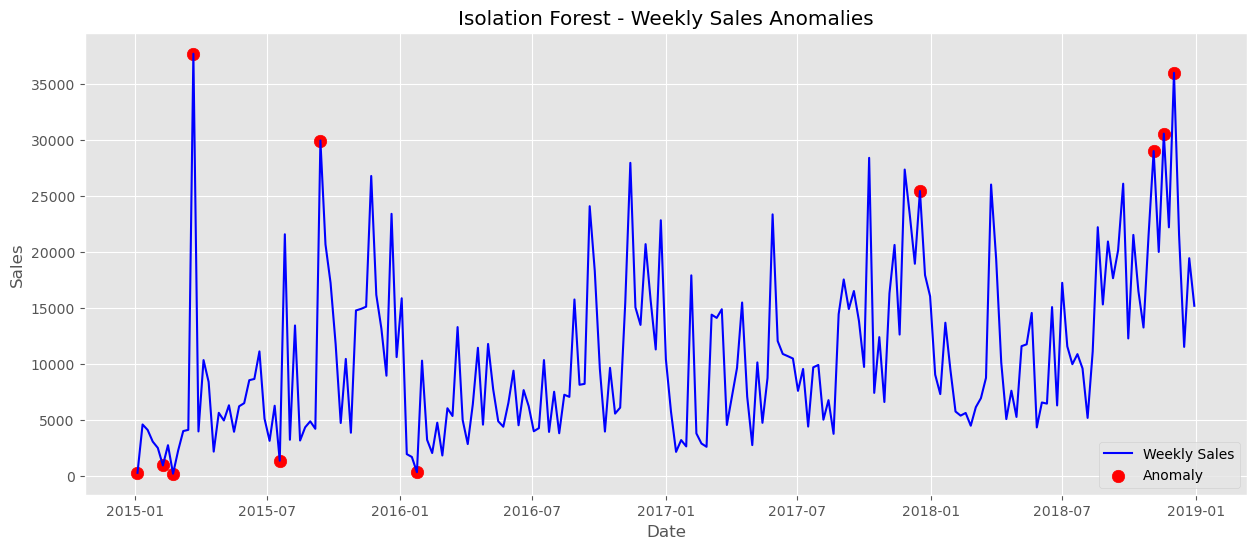

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales.index,
    weekly_sales["Sales"],
    label="Weekly Sales",
    color="blue"
)

anomalies = weekly_sales[
    weekly_sales["IF_Anomaly"] == "Anomaly"
]

plt.scatter(
    anomalies.index,
    anomalies["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest - Weekly Sales Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.savefig(
    "charts/isolation_forest_anomalies.png",
    dpi=300
)

plt.show()

## Isolation Forest Results

The Isolation Forest model detected **11 anomalous weeks** out of **209 total weekly observations**.

The detected anomalies include both unusually high sales weeks and unusually low sales weeks. These observations represent sales values that differ considerably from the normal sales behaviour and may correspond to exceptional business events.

In [ ]:
anomalies

,Sales,IF_Anomaly
Order Date,,
2015-01-04,304.508,Anomaly
2015-02-08,968.534,Anomaly
2015-02-22,224.912,Anomaly
2015-03-22,37703.665,Anomaly
2015-07-19,1387.686,Anomaly
2015-09-13,29959.137,Anomaly
2016-01-24,358.522,Anomaly
2017-12-17,25449.800,Anomaly
2018-11-04,29017.467,Anomaly


## Possible Real-World Explanation of Detected Anomalies

The detected anomalies can be explained by various business scenarios:

- Extremely high sales weeks may correspond to festive seasons, promotional campaigns, year-end discounts, or large corporate purchase orders.
- Extremely low sales weeks may indicate inventory shortages, reduced customer demand, holidays affecting store operations, or temporary supply chain disruptions.
- The unusually high sales observed during late 2018 may be associated with holiday shopping periods and end-of-year promotional events.

## Z-Score Based Anomaly Detection

The Z-Score method is a statistical approach for anomaly detection. It measures how far each week's sales deviate from the rolling mean relative to the rolling standard deviation.

In this project, a week is considered anomalous if its Z-Score exceeds **±2 standard deviations**, indicating unusually high or low sales compared to recent historical behaviour.

In [ ]:
rolling_mean = weekly_sales["Sales"].rolling(
    window=8,
    center=True
).mean()

rolling_std = weekly_sales["Sales"].rolling(
    window=8,
    center=True
).std()

weekly_sales["ZScore"] = (
    weekly_sales["Sales"] - rolling_mean
) / rolling_std

weekly_sales["Z_Anomaly"] = (
    weekly_sales["ZScore"].abs() > 2
)

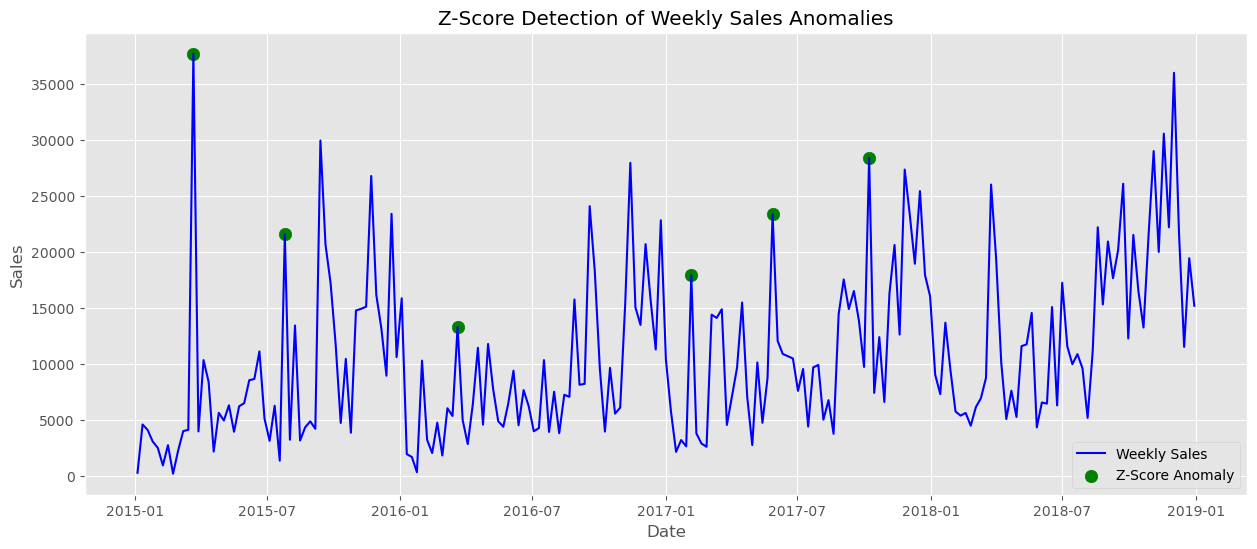

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales.index,
    weekly_sales["Sales"],
    label="Weekly Sales",
    color="blue"
)

z_anomalies = weekly_sales[
    weekly_sales["Z_Anomaly"]
]

plt.scatter(
    z_anomalies.index,
    z_anomalies["Sales"],
    color="green",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Detection of Weekly Sales Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.savefig(
    "charts/zscore_anomalies.png",
    dpi=300
)

plt.show()

## Z-Score Detection Results

The Z-Score method identified several weeks with unusually high sales compared to the surrounding weeks.

Unlike Isolation Forest, which detects both unusually high and unusually low observations, the Z-Score method primarily highlighted sharp positive deviations from the local sales trend.

In [ ]:
z_anomalies

,Sales,IF_Anomaly,ZScore,Z_Anomaly
Order Date,,,,
2015-03-22,37703.665,Anomaly,2.384855,True
2015-07-26,21590.080,Normal,2.088711,True
2016-03-20,13310.136,Normal,2.209014,True
2017-02-05,17926.368,Normal,2.419527,True
2017-05-28,23367.662,Normal,2.105511,True
2017-10-08,28412.098,Normal,2.128709,True


## Comparison of Isolation Forest and Z-Score Methods

The comparison between the two anomaly detection methods shows that they do not identify exactly the same observations.

Isolation Forest detected **11 anomalies**, while the Z-Score method detected **6 anomalies**.

Only **one sales week** was identified as anomalous by both methods. Isolation Forest detected several unusually low sales weeks that were not identified by the Z-Score method, whereas the Z-Score method detected some local sales spikes that Isolation Forest considered part of the normal distribution.

In [ ]:
comparison = pd.DataFrame({
    "Isolation Forest": weekly_sales["IF_Anomaly"] == "Anomaly",
    "Z-Score": weekly_sales["Z_Anomaly"]
})

comparison.value_counts()

Isolation Forest  Z-Score
False             False      193
True              False       10
False             True         5
True              True         1
Name: count, dtype: int64

## Comparison Summary

The comparison results are summarized below:

- Weeks detected by both methods: **1**
- Weeks detected only by Isolation Forest: **10**
- Weeks detected only by Z-Score: **5**
- Weeks considered normal by both methods: **193**

This demonstrates that the two methods use different principles for anomaly detection. Isolation Forest evaluates the overall distribution of the data using a machine learning approach, while the Z-Score method identifies observations that deviate significantly from the rolling average. Using both methods together provides a more comprehensive understanding of unusual sales behaviour.

## Conclusion

Both anomaly detection techniques successfully identified unusual sales weeks within the dataset.

Isolation Forest proved more sensitive by detecting both unusually high and unusually low sales observations across the entire dataset. In contrast, the Z-Score method primarily identified weeks with significant deviations from the local rolling mean.

Overall, Isolation Forest provides a more comprehensive anomaly detection approach for sales forecasting because it captures a wider range of abnormal sales patterns without relying solely on statistical thresholds. Combining machine learning and statistical techniques offers better insight into unusual business events and improves the reliability of anomaly analysis.

# Task 5 — Product Demand Segmentation using K-Means Clustering

In this task, product sub-categories are segmented into different demand groups using the K-Means clustering algorithm. Instead of forecasting sales, clustering identifies products with similar sales behavior to support inventory planning and stocking decisions.

The following features are used for clustering:

- Total Sales Volume
- Sales Growth Rate (Year-over-Year)
- Sales Volatility (Standard Deviation of Monthly Sales)
- Average Order Value

These features provide a comprehensive view of product demand and business performance.

In [ ]:
subcat = df.copy()

subcat["Year"] = subcat["Order Date"].dt.year
subcat["Month"] = subcat["Order Date"].dt.to_period("M")

In [ ]:
monthly_sales = subcat.groupby(
    ["Sub-Category", "Month"]
)["Sales"].sum().reset_index()

monthly_sales.head()

,Sub-Category,Month,Sales
0,Accessories,2015-01,827.890
1,Accessories,2015-02,1120.990
2,Accessories,2015-03,957.734
3,Accessories,2015-04,2323.700
4,Accessories,2015-05,695.490


In [ ]:
feature_df = pd.DataFrame()

feature_df["Total_Sales"] = monthly_sales.groupby(
    "Sub-Category"
)["Sales"].sum()

feature_df["Sales_Volatility"] = monthly_sales.groupby(
    "Sub-Category"
)["Sales"].std()

feature_df["Average_Order_Value"] = subcat.groupby(
    "Sub-Category"
)["Sales"].mean()

In [ ]:
yearly_sales = subcat.groupby(
    ["Sub-Category", "Year"]
)["Sales"].sum().unstack(fill_value=0)

growth = (
    yearly_sales.iloc[:, -1] -
    yearly_sales.iloc[:, 0]
) / yearly_sales.iloc[:, 0] * 100

feature_df["Growth_Rate"] = growth

feature_df = feature_df.fillna(0)

feature_df

,Total_Sales,Sales_Volatility,Average_Order_Value,Growth_Rate
Sub-Category,,,,
Accessories,164186.7000,2579.994809,217.178175,145.055961
Appliances,104618.4030,1821.621539,227.926804,165.242912
Art,26705.4100,330.488343,34.019631,49.649531
Binders,200028.7850,3848.223648,134.067550,65.778638
Bookcases,113813.1987,2220.405080,503.598224,49.846598
Chairs,322822.7310,4407.232960,531.833165,20.954677
Copiers,146248.0940,5500.774391,2215.880212,479.729510
Envelopes,16128.0460,228.218688,65.032444,-12.121345
Fasteners,3001.9600,48.742229,14.027850,30.468364


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(feature_df)

scaled_features

array([[ 0.31598599,  0.08508503, -0.36354857,  0.60316135],
       [-0.28817617, -0.34706199, -0.34520236,  0.78345815],
       [-1.07839653, -1.19676068, -0.67617125, -0.24894717],
       [ 0.67950874,  0.80776519, -0.50540527, -0.10489242],
       [-0.19491939, -0.11982149,  0.12532518, -0.2471871 ],
       [ 1.92492716,  1.12630781,  0.17351776, -0.50523105],
       [ 0.13404648,  1.74944512,  3.04791985,  3.59224905],
       [-1.18567579, -1.25503743, -0.62323728, -0.80064468],
       [-1.31880507, -1.35730925, -0.71029406, -0.42026095],
       [-0.44443302, -0.61009955, -0.57068119,  0.26170686],
       [-1.2240171 , -1.2577427 , -0.67520204, -0.37020064],
       [ 0.57007129,  1.80801288,  2.07446199, -0.95847755],
       [-0.57003291, -0.80110392, -0.63623008,  0.12842429],
       [ 1.97523032,  0.92429319, -0.09556978, -0.37480712],
       [ 0.87540412,  0.22303591, -0.28425602, -0.34972341],
       [-0.87844126, -0.23111635, -0.30362799, -0.59167439],
       [ 0.70772315,  0.

## Determining the Optimal Number of Clusters

Before applying K-Means, the Elbow Method is used to determine the optimal number of clusters.

The Elbow Method plots the inertia (within-cluster sum of squares) against different values of K. The point where the reduction in inertia begins to slow significantly is selected as the optimal number of clusters.

Based on the elbow curve, three clusters were selected for product demand segmentation.

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)

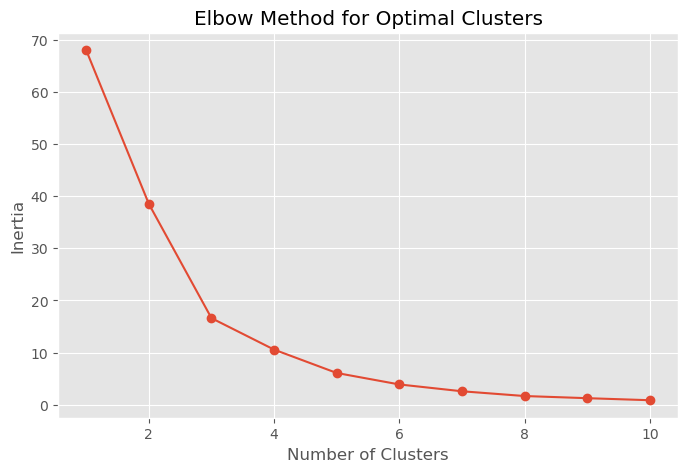

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Clusters")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(True)

plt.savefig(
    "charts/elbow_method.png",
    dpi=300
)
plt.savefig(
    "charts/kmeans_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Elbow Method Interpretation

The elbow plot shows a significant decrease in inertia until K = 3, after which the improvement becomes marginal.

Therefore, three clusters are chosen as the optimal solution because they provide a good balance between cluster compactness and model simplicity.

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

feature_df["Cluster"] = kmeans.fit_predict(scaled_features)

feature_df

,Total_Sales,Sales_Volatility,Average_Order_Value,Growth_Rate,Cluster
Sub-Category,,,,,
Accessories,164186.7000,2579.994809,217.178175,145.055961,1
Appliances,104618.4030,1821.621539,227.926804,165.242912,1
Art,26705.4100,330.488343,34.019631,49.649531,1
Binders,200028.7850,3848.223648,134.067550,65.778638,2
Bookcases,113813.1987,2220.405080,503.598224,49.846598,1
Chairs,322822.7310,4407.232960,531.833165,20.954677,2
Copiers,146248.0940,5500.774391,2215.880212,479.729510,0
Envelopes,16128.0460,228.218688,65.032444,-12.121345,1
Fasteners,3001.9600,48.742229,14.027850,30.468364,1


## Product Demand Clusters

After training the K-Means model, Principal Component Analysis (PCA) is used to reduce the four-dimensional feature space into two principal components for visualization.

Each point in the scatter plot represents one product sub-category, while colors indicate the assigned demand cluster.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

In [ ]:
plot_df = feature_df.copy()

plot_df["PCA1"] = pca_features[:,0]

plot_df["PCA2"] = pca_features[:,1]

plot_df

,Total_Sales,Sales_Volatility,Average_Order_Value,Growth_Rate,Cluster,PCA1,PCA2
Sub-Category,,,,,,,
Accessories,164186.7000,2579.994809,217.178175,145.055961,1,0.200367,0.116729
Appliances,104618.4030,1821.621539,227.926804,165.242912,1,-0.264248,0.707660
Art,26705.4100,330.488343,34.019631,49.649531,1,-1.676784,0.535820
Binders,200028.7850,3848.223648,134.067550,65.778638,2,0.484161,-0.805597
Bookcases,113813.1987,2220.405080,503.598224,49.846598,1,-0.176589,0.003166
Chairs,322822.7310,4407.232960,531.833165,20.954677,2,1.479554,-1.711393
Copiers,146248.0940,5500.774391,2215.880212,479.729510,0,4.046026,2.979941
Envelopes,16128.0460,228.218688,65.032444,-12.121345,1,-1.920711,0.234844
Fasteners,3001.9600,48.742229,14.027850,30.468364,1,-1.960973,0.583155


## Cluster Interpretation

The clustering algorithm successfully grouped the product sub-categories into three distinct demand segments.

### Cluster 0 – High Value Premium Products
This cluster contains premium products with exceptionally high average order values and strong sales growth. Copiers fall into this category due to their high revenue per transaction and rapid growth.

### Cluster 1 – Low to Medium Volume Stable Products
This cluster includes products such as Accessories, Appliances, Art, Envelopes, Fasteners, Furnishings, Labels, Paper, Supplies, and Bookcases. These products generally have lower sales volumes and relatively stable demand patterns.

### Cluster 2 – High Volume Core Products
This cluster includes Chairs, Phones, Storage, Tables, Machines, and Binders. These products generate high sales volumes and represent the primary revenue-driving product categories.

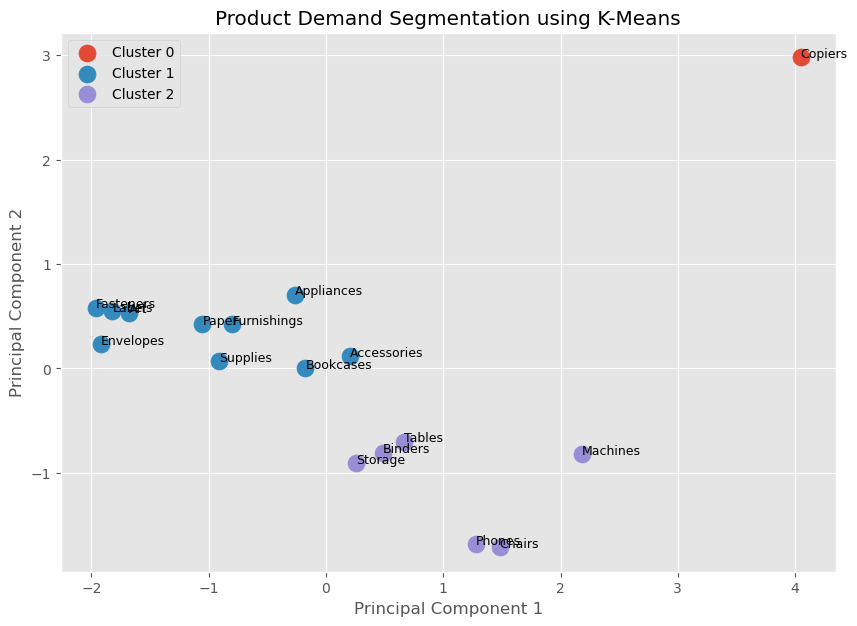

In [ ]:
plt.figure(figsize=(10,7))

for cluster in sorted(plot_df["Cluster"].unique()):

    cluster_data = plot_df[
        plot_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        s=150,
        label=f"Cluster {cluster}"
    )

for idx in plot_df.index:

    plt.text(
        plot_df.loc[idx,"PCA1"],
        plot_df.loc[idx,"PCA2"],
        idx,
        fontsize=9
    )

plt.title("Product Demand Segmentation using K-Means")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(True)

plt.savefig(
    "charts/product_clusters.png",
    dpi=300
)

plt.show()

## Recommended Stocking Strategy

Based on the clustering results, the following inventory strategies are recommended:

### Cluster 0 – High Value Premium Products
- Maintain limited but carefully managed inventory.
- Monitor supplier lead times closely.
- Avoid stock-outs due to high profit margins.

### Cluster 1 – Low to Medium Volume Stable Products
- Maintain moderate inventory levels.
- Use periodic replenishment based on historical demand.
- Minimize excess inventory to reduce holding costs.

### Cluster 2 – High Volume Core Products
- Maintain higher inventory levels.
- Prioritize continuous replenishment.
- Apply demand forecasting regularly to avoid shortages during peak demand periods.

## Conclusion

The K-Means clustering model successfully segmented the product sub-categories into three meaningful demand groups based on sales performance, volatility, growth rate, and average order value.

The clustering results provide valuable business insights for inventory planning and supply chain management. High-volume products should receive priority in stock replenishment, while premium products require careful inventory control due to their high value. Stable products can be managed using regular replenishment strategies to optimize storage costs and product availability.